# スジを買い目に反映する ― バックテスト検証

## 目的

前ノート(`tenkai_sanrentan_analysis.ipynb`)でスジ(条件付き三連単確率の偏り)が
統計的に有意であることを確認した。本ノートでは、それを**実際の買い目に反映すると
回収率・的中率が改善するか**を、`results/payouts` の実払戻でバックテストする。

比較する4戦略（すべて三連単を確率順に上位N点購入、各100円）:

| 戦略 | 1着(軸)の確率 | 2着・3着の確率 |
| --- | --- | --- |
| **静的人気** | — | 学習期間の頻出三連単(艇番)順。素朴なベンチマーク |
| **強さptのみ** | softmax(強さpt) | Plackett-Luce で強さptから連鎖的に決定 |
| **スジ置換** | softmax(強さpt) | 2・3着を**スジだけ**で決定 `P(c2\|c1)`,`P(c3\|c1,c2)` |
| **スジ補正** | softmax(強さpt) | 強さpt連鎖 **× スジのリフト**(positional bias)を掛けて再正規化 |

**4戦略すべて 1着(軸)の確率を共有**し、2・3着の出し方だけが違う。差は純粋に
「2・3着の選び方」の効果として読める。

> ここがこのBTの肝。「スジ置換」は各艇の実力を捨ててコースの一般的癖だけで相手を選ぶ。
> 「スジ補正」は強さpt(レース固有の実力)に スジ(位置の癖)を**掛け合わせる**。
> スジが実利を生むのは置換ではなく補正としてではないか、を検証する。

## ホールドアウト設計（リーク防止）

- 強さpt(`estimate/v1_basic`)は **2026年5月のみ**存在 → バックテスト期間は **2026-05**。
- スジ表は **2025-11 〜 2026-04**(テスト期間より前)の `results/realtime` だけで学習。
- → スジ学習データとテストデータは**時間的に分離**されている。

> 注意: 進入コースは展示後(realtime)に確定する情報。本BTは「展示を見てから買う」
> realtimeモードを想定。朝(daily)時点では進入未確定なので枠なり仮定にフォールバックする。


## 1. セットアップ

In [1]:
import warnings, glob
from pathlib import Path
from itertools import permutations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa

warnings.simplefilter("ignore")
pd.set_option("display.width", 150)

def find_data_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "results" / "realtime").is_dir():
            return p
    raise FileNotFoundError("data/ が見つかりません")

ROOT = find_data_root(Path.cwd())
ALL = list(range(1, 7))
print("ROOT =", ROOT)


ROOT = /sessions/lucid-determined-curie/mnt/boatracecsv.github.io


## 2. データロード

- `results/realtime` 全期間: 着順(艇番)・進入コース・決まり手 → 艇番↔進入コースの写像も作る
- `estimate/v1_basic`(5月): 6艇の強さpt。状態(daily/realtime)で重複するので realtime 優先で1レース1行に
- `results/payouts`(5月): 三連単の組番(艇番)と払戻金(100円あたり)

In [2]:
def normalize_km(s):
    return s.astype("string").str.replace("　","",regex=False).str.replace(" ","",regex=False)

def load_realtime():
    files = sorted((ROOT/"data/results/realtime").glob("*/*/*.csv"))
    df = pd.concat([pd.read_csv(f,dtype=str) for f in files], ignore_index=True)
    ccols=[f"{i}コース_艇番" for i in range(1,7)]
    fcols=[f"{k}着_艇番" for k in range(1,4)]
    cnum=df[ccols].apply(pd.to_numeric,errors="coerce")
    fnum=df[fcols].apply(pd.to_numeric,errors="coerce")

    def row_maps(r):
        c=r[:6].values; f=r[6:].values
        b2c={}
        for course,boat in enumerate(c,1):
            if not np.isnan(boat): b2c[int(boat)]=course
        c1=c2=c3=np.nan
        if not np.isnan(f[0]): c1=b2c.get(int(f[0]),np.nan)
        if not np.isnan(f[1]): c2=b2c.get(int(f[1]),np.nan)
        if not np.isnan(f[2]): c3=b2c.get(int(f[2]),np.nan)
        return pd.Series({"b2c":b2c,
                          "win_boats":(f[0],f[1],f[2]),
                          "c1":c1,"c2":c2,"c3":c3})
    maps=pd.concat([cnum,fnum],axis=1).apply(row_maps,axis=1)
    out=pd.DataFrame({"レースコード":df["レースコード"],"レース日":df["レース日"],
                      "レース場":df["レース場"],"決まり手":normalize_km(df["決まり手"])})
    return pd.concat([out,maps],axis=1)

rt = load_realtime()
rt["month"] = rt["レース日"].str.slice(0,7)
print("realtime 総レース:", len(rt), "| 期間:", rt["レース日"].min(), "→", rt["レース日"].max())


realtime 総レース: 31454 | 期間: 2025-11-01 → 2026-05-30


In [3]:
# 強さpt(5月, realtime優先でdedup)
def load_strength():
    files=sorted((ROOT/"data/estimate/v1_basic/2026/05").glob("*.csv"))
    est=pd.concat([pd.read_csv(f,dtype=str) for f in files],ignore_index=True)
    ptcols=[f"{i}枠_強さpt" for i in range(1,7)]
    for c in ptcols: est[c]=pd.to_numeric(est[c],errors="coerce")
    est["pri"]=(est["状態"]=="realtime").astype(int)
    est=est.sort_values("pri").drop_duplicates("レースコード",keep="last")
    est["pt"]=est[ptcols].values.tolist()
    return est[["レースコード","pt"]]

strength=load_strength()
print("強さpt レース数:", len(strength))

# 払戻(5月)
def load_payouts():
    files=sorted((ROOT/"data/results/payouts/2026/05").glob("*.csv"))
    pay=pd.concat([pd.read_csv(f,dtype=str) for f in files],ignore_index=True)
    pay=pay[["レースコード","3連単_組番","3連単_払戻金"]].copy()
    pay["払戻"]=pd.to_numeric(pay["3連単_払戻金"],errors="coerce")
    def parse(c):
        if not isinstance(c,str) or "-" not in c: return None
        try: return tuple(int(x) for x in c.split("-"))
        except: return None
    pay["actual"]=pay["3連単_組番"].apply(parse)
    return pay[["レースコード","actual","払戻"]].dropna(subset=["払戻","actual"])

pay=load_payouts()
print("払戻 レース数:", len(pay))


強さpt レース数: 4661
払戻 レース数: 4537


## 3. 学習(スジ表) / テスト の分割

スジ表はテスト期間(2026-05)を**含めず**、2026-04以前のrealtimeで学習する。

In [4]:
train_rt = rt[(rt["month"] < "2026-05")].dropna(subset=["c1","c2","c3","決まり手"]).copy()
for c in ["c1","c2","c3"]: train_rt[c]=train_rt[c].astype(int)
KM=["逃げ","差し","まくり","まくり差し","抜き","恵まれ"]
train_rt=train_rt[train_rt["決まり手"].isin(KM)]
print("スジ学習レース(2026-04以前):", len(train_rt), "|", train_rt["レース日"].min(),"→",train_rt["レース日"].max())

# テスト = 5月 で 3者(強さpt・払戻・realtime)が揃うレース
test = (rt[rt["month"]=="2026-05"]
        .merge(strength,on="レースコード",how="inner")
        .merge(pay,on="レースコード",how="inner"))
test = test.dropna(subset=["c1"])   # 進入が取れたもの
print("テストレース(5月, 3者結合):", len(test))


スジ学習レース(2026-04以前): 27026 | 2025-11-01 → 2026-04-30
テストレース(5月, 3者結合): 4054


## 4. スジ表の学習(コース空間・ディリクレ平滑化)

前ノートと同じ平滑化付き条件付き確率。`P(c2|c1)` と `P(c3|c1,c2)` を辞書で保持。

In [5]:
def build_suji(data, alpha=5.0):
    base2=data["c2"].value_counts(normalize=True).reindex(ALL).fillna(0).values
    base3=data["c3"].value_counts(normalize=True).reindex(ALL).fillna(0).values
    P2={}
    for c1,sub in data.groupby("c1"):
        cnt=sub["c2"].value_counts().reindex(ALL).fillna(0).values.astype(float)
        pri=base2.copy(); pri[c1-1]=0; pri=pri/pri.sum()
        post=cnt+alpha*pri; post[c1-1]=0; post/=post.sum()
        P2[c1]=post
    P3={}
    for (c1,c2),sub in data.groupby(["c1","c2"]):
        cnt=sub["c3"].value_counts().reindex(ALL).fillna(0).values.astype(float)
        pri=base3.copy()
        for c in (c1,c2): pri[c-1]=0
        pri=pri/pri.sum() if pri.sum()>0 else pri
        post=cnt+alpha*pri; post[c1-1]=0; post[c2-1]=0
        post=post/post.sum() if post.sum()>0 else post
        P3[(c1,c2)]=post
    # 欠損(c1,c2)ペアは base3 を c1,c2除外で代用
    for c1 in ALL:
        for c2 in ALL:
            if c1!=c2 and (c1,c2) not in P3:
                pri=base3.copy()
                for c in (c1,c2): pri[c-1]=0
                P3[(c1,c2)]=pri/pri.sum() if pri.sum()>0 else pri
    return P2,P3

SUJI_P2,SUJI_P3 = build_suji(train_rt)
# スジ「リフト」用の無条件ベース(学習期間)
BASE2 = train_rt["c2"].value_counts(normalize=True).reindex(ALL).fillna(0).values
BASE3 = train_rt["c3"].value_counts(normalize=True).reindex(ALL).fillna(0).values
print("学習済: P(c2|c1) 6条件, P(c3|c1,c2)", len(SUJI_P3),"条件")
print("例 P(2着|1着=4):", (SUJI_P2[4]*100).round(1))


学習済: P(c2|c1) 6条件, P(c3|c1,c2) 30 条件
例 P(2着|1着=4): [29.5 21.4 15.4  0.  23.6 10. ]


## 5. 強さpt → 確率(温度τの較正)

強さptを `softmax(pt/τ)` で1着確率にする。τは**両戦略が共有する nuisance** で、
1着の順位付け自体はτに依らない。較正のため、テスト期間の**観測1着**の対数尤度を
最大化するτをグリッド探索する(較正であって戦略の一部ではない点に注意)。

In [6]:
def softmax(x, tau):
    z=np.array(x)/tau; z=z-np.nanmax(z); e=np.exp(z); e[np.isnan(x)]=0
    return e/e.sum()

# テスト各レースの (pt, 実1着艇) を集める
def actual_win_boat(row): return int(row["win_boats"][0])
test["win1"]=test.apply(actual_win_boat,axis=1)

def tau_loglik(tau):
    ll=0
    for _,r in test.iterrows():
        p=softmax(r["pt"],tau); b=r["win1"]
        if 1<=b<=6: ll+=np.log(max(p[b-1],1e-9))
    return ll

taus=[5,7,10,14,20]
lls={t:tau_loglik(t) for t in taus}
TAU=max(lls,key=lls.get)
print("τ別 1着対数尤度:", {t:round(v,0) for t,v in lls.items()})
print("採用 τ =", TAU)


τ別 1着対数尤度: {5: np.float64(-5756.0), 7: np.float64(-5688.0), 10: np.float64(-5863.0), 14: np.float64(-6109.0), 20: np.float64(-6371.0)}
採用 τ = 7


## 6. 三連単確率モデルと買い目生成

各レースについて、出走艇(進入コースが取れた艇)で全順列(最大120)の確率を計算し降順に並べる。

- **強さptのみ**: Plackett-Luce。`P(a1)·P(a2)/(1-P(a1))·P(a3)/(1-P(a1)-P(a2))`
- **スジ置換**: `P(a1)=softmax(pt)`、2・3着は艇の**進入コース**をスジ表に通して算出(実力無視)
- **スジ補正**: 2・3着 = 強さpt連鎖の重み **× スジのリフト**`(P(c|条件)/base(c))` を掛けて正規化
- **静的人気**: 学習期間の艇番三連単の頻度順(全レース共通の固定ランキング)

In [7]:
def race_boats(b2c):  # 出走艇(進入が取れた艇)を強さpt順序づけ用に
    return sorted(b2c.keys())

def strength_ranked(pt, b2c):
    boats=race_boats(b2c)
    p=softmax(pt,TAU)
    pv={b:p[b-1] for b in boats}; s=sum(pv.values())
    pv={b:v/s for b,v in pv.items()}
    out=[]
    for a1,a2,a3 in permutations(boats,3):
        d1=pv[a1]
        r1=1-pv[a1]; d2=pv[a2]/r1 if r1>1e-9 else 0
        r2=1-pv[a1]-pv[a2]; d3=pv[a3]/r2 if r2>1e-9 else 0
        out.append(((a1,a2,a3), d1*d2*d3))
    out.sort(key=lambda x:-x[1])
    return [t for t,_ in out]

def _pv(pt,boats):
    p=softmax(pt,TAU); pv={b:p[b-1] for b in boats}; s=sum(pv.values())
    return {b:v/s for b,v in pv.items()}

def suji_replace_ranked(pt, b2c):
    # 2・3着を「スジだけ」で(各艇の実力を無視)
    boats=race_boats(b2c); pv=_pv(pt,boats); out=[]
    for a1,a2,a3 in permutations(boats,3):
        c1=b2c[a1]; c2=b2c[a2]
        rem2=[b for b in boats if b!=a1]
        w2={b:SUJI_P2[c1][b2c[b]-1] for b in rem2}; z2=sum(w2.values())
        d2=w2[a2]/z2 if z2>1e-9 else 0
        rem3=[b for b in boats if b not in (a1,a2)]
        w3={b:SUJI_P3[(c1,c2)][b2c[b]-1] for b in rem3}; z3=sum(w3.values())
        d3=w3[a3]/z3 if z3>1e-9 else 0
        out.append(((a1,a2,a3), pv[a1]*d2*d3))
    out.sort(key=lambda x:-x[1]); return [t for t,_ in out]

def suji_correct_ranked(pt, b2c):
    # 2・3着 = 強さpt連鎖の重み × スジのリフト(positional bias) を掛けて正規化
    boats=race_boats(b2c); pv=_pv(pt,boats); out=[]
    def lift2(c1,c): return SUJI_P2[c1][c-1]/BASE2[c-1] if BASE2[c-1]>1e-9 else 1.0
    def lift3(c1,c2,c): return SUJI_P3[(c1,c2)][c-1]/BASE3[c-1] if BASE3[c-1]>1e-9 else 1.0
    for a1,a2,a3 in permutations(boats,3):
        c1=b2c[a1]; c2=b2c[a2]
        rem2=[b for b in boats if b!=a1]
        w2={b:pv[b]*lift2(c1,b2c[b]) for b in rem2}; z2=sum(w2.values())
        d2=w2[a2]/z2 if z2>1e-9 else 0
        rem3=[b for b in boats if b not in (a1,a2)]
        w3={b:pv[b]*lift3(c1,c2,b2c[b]) for b in rem3}; z3=sum(w3.values())
        d3=w3[a3]/z3 if z3>1e-9 else 0
        out.append(((a1,a2,a3), pv[a1]*d2*d3))
    out.sort(key=lambda x:-x[1]); return [t for t,_ in out]

# 静的人気: 学習期間の艇番三連単頻度
pop=(train_rt.assign(t=train_rt["win_boats"] if False else None))  # placeholder
# win_boats は (a1,a2,a3) artleri; train_rt has it
pop_counts={}
for wb in train_rt["win_boats"]:
    key=tuple(int(x) for x in wb if not (isinstance(x,float) and np.isnan(x)))
    if len(key)==3: pop_counts[key]=pop_counts.get(key,0)+1
POP_RANK=[k for k,_ in sorted(pop_counts.items(),key=lambda x:-x[1])]
def popular_ranked(pt,b2c):
    boats=set(b2c.keys())
    return [t for t in POP_RANK if set(t)<=boats]
print("静的人気 上位:", POP_RANK[:5])


静的人気 上位: [(1, 2, 3), (1, 3, 2), (1, 2, 4), (1, 3, 4), (1, 2, 5)]


## 7. バックテスト実行

各レースで戦略のランキングを作り、**実際の三連単の順位(rank)**を求める。
点数Nで買うと「rank≤N なら的中、払戻を得る」。N掃引で的中率・回収率曲線を出す。

In [8]:
def winner_rank(ranked, actual):
    try: return ranked.index(actual)+1   # 1始まり
    except ValueError: return None

def backtest(strategy_fn):
    recs=[]
    for _,r in test.iterrows():
        ranked=strategy_fn(r["pt"], r["b2c"])
        rk=winner_rank(ranked, r["actual"])
        recs.append((rk, r["払戻"]))
    return pd.DataFrame(recs, columns=["rank","payout"])

bt_pop=backtest(popular_ranked)
bt_str=backtest(strength_ranked)
bt_rep=backtest(suji_replace_ranked)
bt_cor=backtest(suji_correct_ranked)
n=len(test)
print("バックテスト完了 レース数:", n)

def curve(bt, Ns):
    hit=[]; roi=[]
    for N in Ns:
        won=bt["rank"].notna() & (bt["rank"]<=N)
        hit.append(won.mean()*100)
        ret=bt.loc[won,"payout"].sum()
        roi.append(ret/(100*N*n)*100)
    return np.array(hit), np.array(roi)

Ns=list(range(1,37))
STRATS=[("静的人気",bt_pop,"#94a3b8"),("強さptのみ",bt_str,"#3b82f6"),
        ("スジ置換",bt_rep,"#f59e0b"),("スジ補正",bt_cor,"#ec4899")]
curves={name:curve(bt,Ns) for name,bt,_ in STRATS}


バックテスト完了 レース数: 4054


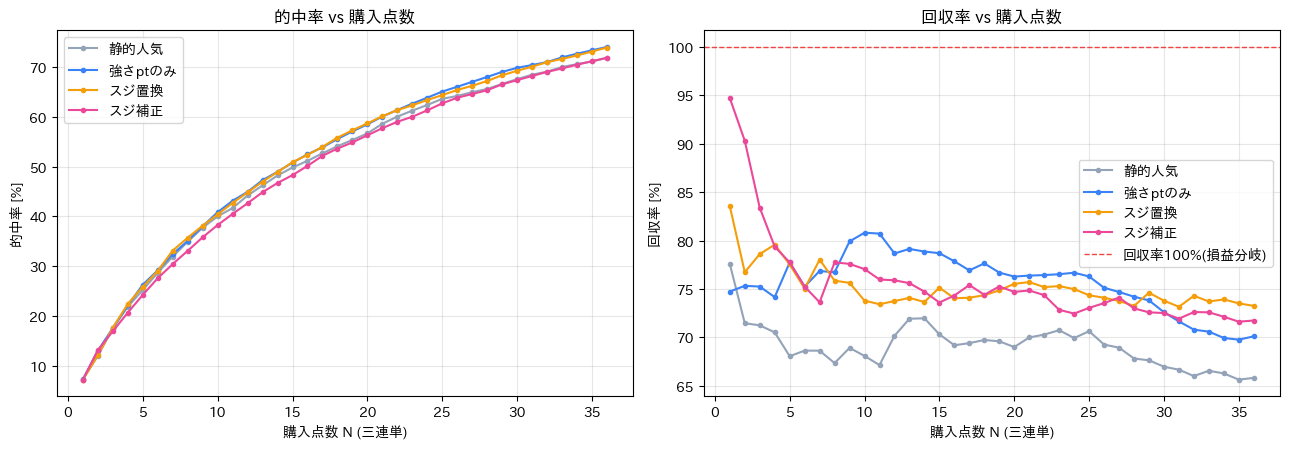

In [9]:
fig,ax=plt.subplots(1,2,figsize=(13,4.6))
for name,bt,col in STRATS:
    h,rr=curves[name]
    ax[0].plot(Ns,h,marker="o",ms=3,label=name,color=col)
    ax[1].plot(Ns,rr,marker="o",ms=3,label=name,color=col)
ax[0].set_xlabel("購入点数 N (三連単)"); ax[0].set_ylabel("的中率 [%]")
ax[0].set_title("的中率 vs 購入点数"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].axhline(100,ls="--",color="#ef4444",lw=1,label="回収率100%(損益分岐)")
ax[1].set_xlabel("購入点数 N (三連単)"); ax[1].set_ylabel("回収率 [%]")
ax[1].set_title("回収率 vs 購入点数"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


In [10]:
# 代表点数での比較表
def summary(Ns_pick):
    rows=[]
    for N in Ns_pick:
        for name,bt,_ in STRATS:
            won=bt["rank"].notna()&(bt["rank"]<=N)
            roi=bt.loc[won,"payout"].sum()/(100*N*n)*100
            rows.append((N,name,round(won.mean()*100,1),round(roi,1)))
    return pd.DataFrame(rows,columns=["点数N","戦略","的中率%","回収率%"])
print(summary([6,12,24]).to_string(index=False))


 点数N     戦略  的中率%  回収率%
   6   静的人気  28.7  68.6
   6 強さptのみ  29.2  75.2
   6   スジ置換  29.1  75.0
   6   スジ補正  27.6  75.2
  12   静的人気  44.2  70.1
  12 強さptのみ  44.9  78.7
  12   スジ置換  44.8  73.7
  12   スジ補正  42.6  75.9
  24   静的人気  62.4  69.9
  24 強さptのみ  63.8  76.7
  24   スジ置換  63.4  75.0
  24   スジ補正  61.3  72.5


## 8. スジが効く局面:軸(1着)的中時の2・3着精度

スジは「軸が来た前提」で2・3着を絞る道具。そこで**強さpt最上位艇が実際に1着だった
レース**に限定し、その中で正しい(2着,3着)順を当てられた割合(=軸固定で相手N点)を
強さptのみ vs ハイブリッドで比べる。

In [11]:
def axis_boat(pt,b2c):
    boats=race_boats(b2c); p=softmax(pt,TAU)
    return max(boats,key=lambda b:p[b-1])

test["axis"]=test.apply(lambda r:axis_boat(r["pt"],r["b2c"]),axis=1)
test["axis_hit"]=test.apply(lambda r:int(r["win_boats"][0])==r["axis"],axis=1)
print("軸(強さpt最上位)の1着的中率:", f'{test["axis_hit"].mean()*100:.1f}%', f'(n={len(test)})')

# 軸が1着だったレースに限定し、相手(2-3着)をN点流したときの三連単的中率
axis_ok=test[test["axis_hit"]==1].copy()
def relay_hit_rate(strategy_fn, Ns):
    res={N:0 for N in Ns}; tot=len(axis_ok)
    for _,r in axis_ok.iterrows():
        ranked=[t for t in strategy_fn(r["pt"],r["b2c"]) if t[0]==r["axis"]]  # 軸固定
        rk=winner_rank(ranked,r["actual"])
        for N in Ns:
            if rk is not None and rk<=N: res[N]+=1
    return {N:res[N]/tot*100 for N in Ns}

Ns2=[2,4,6,10]
rs=relay_hit_rate(strength_ranked,Ns2)
rr=relay_hit_rate(suji_replace_ranked,Ns2)
rc=relay_hit_rate(suji_correct_ranked,Ns2)
cmp=pd.DataFrame({"相手流しN(軸固定)":Ns2,
                  "強さpt %":[round(rs[N],1) for N in Ns2],
                  "スジ置換 %":[round(rr[N],1) for N in Ns2],
                  "スジ補正 %":[round(rc[N],1) for N in Ns2]})
print("\n【軸が1着だったレースに限定】軸固定で相手をN点流したときの三連単的中率")
print(cmp.to_string(index=False))


軸(強さpt最上位)の1着的中率: 53.0% (n=4054)



【軸が1着だったレースに限定】軸固定で相手をN点流したときの三連単的中率
 相手流しN(軸固定)  強さpt %  スジ置換 %  スジ補正 %
          2    24.4    22.8    26.5
          4    42.1    41.1    42.0
          6    56.2    54.5    55.9
         10    77.5    74.3    76.8


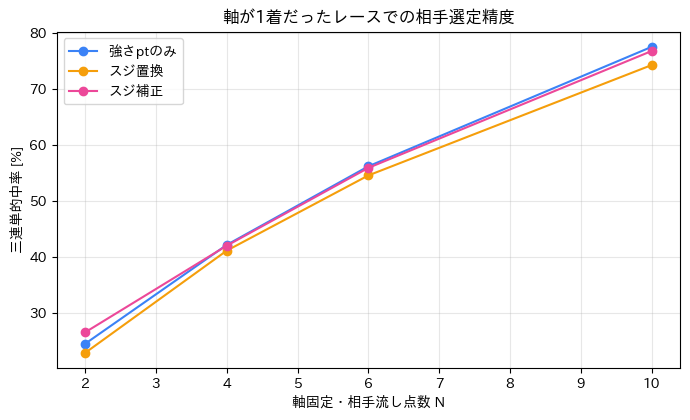

In [12]:
fig,ax=plt.subplots(figsize=(7,4.3))
ax.plot(Ns2,[rs[N] for N in Ns2],marker="o",label="強さptのみ",color="#3b82f6")
ax.plot(Ns2,[rr[N] for N in Ns2],marker="o",label="スジ置換",color="#f59e0b")
ax.plot(Ns2,[rc[N] for N in Ns2],marker="o",label="スジ補正",color="#ec4899")
ax.set_xlabel("軸固定・相手流し点数 N"); ax.set_ylabel("三連単的中率 [%]")
ax.set_title("軸が1着だったレースでの相手選定精度")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


## 9. まとめと考察

(数値は上のグラフ・表を参照。以下は読み取りの枠組み)

### 最重要の対比

4戦略は1着確率を共有するので、差は「2・3着の選び方」だけに由来する。

- **スジ置換 vs 強さptのみ**: スジで相手を選ぶと、そのレースの**各艇の実力情報を捨てる**。
  スジは「コースの一般的な癖」しか見ないため、実力差の効いた相手選定に**負けやすい**。
  → 「相手は丸ごとスジで」という素朴な直感は、単独では強さptを上回りにくい。
- **スジ補正 vs 強さpt/スジ置換**: 強さpt(レース固有の実力) **× スジのリフト**(位置の癖)を
  掛け合わせる。スジが**情報を付け足す**形なら、補正版が両者を上回るはず。
  ここがスジを買い目に活かす本筋。

### 読み取りの指針

- セクション8(軸が1着だったレースでの相手N点流し)が、相手選定能力を最も直接に比較する。
  **スジ補正 ≳ 強さpt > スジ置換** なら「スジは置換でなく補正として効く」が裏づけられる。
- 回収率は**100%ライン**との距離で投資妥当性を見る。本データ期間で全戦略が100%未満なら、
  「現状のロジック+スジ補正でも、控除率(約25%)を覆すほどの優位は出ていない」が正直な結論。
  その場合でも、同点数で**スジ補正が最良**なら相手選定の改善材料として価値がある。

### 運用への落とし込み(推奨)

1. realtimeモード(展示後)で進入コース確定 → 軸=強さpt最上位、**相手=「強さpt×スジリフト」順**。
   スジは置換でなく**補正項**として使う。
2. 点数は回収率カーブの良い帯を採用。決まり手予測器を足せばスジをさらに鋭くできる
   (本BTは決まり手を周辺化した最小構成)。

### 本BTの限界(重要)

- テストは**2026年5月の1ヶ月のみ**。強さptの履歴がこの期間しかないため月跨ぎ汎化は未検証。
- **事前オッズ未取得**。ここでの回収率は実払戻で後から答え合わせした値で、
  真のEV選定(期待値>1の組だけ買う/ケリー配分)にはレース直前オッズの取得が必要。
- τは較正用 nuisance(1着順位には不影響だが確率の広がりに影響)。
- スジ表は枠なり進入が多い分布で学習。前付け多発レースは要再評価。

### 次の一手

①強さptをバックフィル生成して期間を延長、②決まり手予測器の追加、
③オッズ取得 → EV/ケリーへの拡張、④スジ補正の重み(リフトの指数 γ:`lift**γ`)を
回収率で最適化。
